In [3]:
import pandas as pd
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

# File name
SMOTE_DATA_FILE_NAME = "loan_data_smoted_raw_train_4.csv"
RAW_DATA_FILE_NAME = "loan_data_raw_test_1.csv"
PROJECT_ROOT = Path("..")
SMOTE_DATA_FILE_PATH = PROJECT_ROOT / "data" / "smote" / SMOTE_DATA_FILE_NAME
RAW_DATA_FILE_PATH = PROJECT_ROOT / "data" / "raw" / RAW_DATA_FILE_NAME
print("PROJECT_ROOT:", PROJECT_ROOT)
print("Smote data path:", SMOTE_DATA_FILE_PATH)
print("Raw data path:", RAW_DATA_FILE_PATH)

df = pd.read_csv(SMOTE_DATA_FILE_PATH)
print(df.shape)
df.head()

PROJECT_ROOT: ..
Smote data path: ..\data\smote\loan_data_smoted_raw_train_4.csv
Raw data path: ..\data\raw\loan_data_raw_test_1.csv
(53530, 13)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
0,31.0,female,2,44485.0,4,RENT,8000.0,PERSONAL,8.83,0.18,8.0,668,0
1,24.0,female,4,35851.0,0,RENT,8725.0,MEDICAL,12.18,0.24,2.0,645,0
2,28.0,female,1,121251.0,6,MORTGAGE,25000.0,VENTURE,11.01,0.21,6.0,569,1
3,23.0,female,1,76537.0,1,RENT,12000.0,MEDICAL,14.96,0.16,4.0,538,1
4,24.0,male,2,53633.0,4,RENT,23975.0,HOMEIMPROVEMENT,11.01,0.45,2.0,678,1


In [4]:
test_df = pd.read_csv(RAW_DATA_FILE_PATH)
print(test_df.shape)
test_df.head()

(8999, 13)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
0,24.0,male,4,100901.0,5,RENT,5000.0,HOMEIMPROVEMENT,16.35,0.05,3.0,602,0
1,34.0,male,2,96600.0,15,RENT,5000.0,HOMEIMPROVEMENT,6.17,0.05,10.0,614,0
2,29.0,male,3,75404.0,1,MORTGAGE,3104.0,PERSONAL,12.76,0.04,8.0,657,0
3,30.0,female,1,43211.0,5,OWN,10000.0,EDUCATION,6.04,0.23,9.0,645,0
4,22.0,female,4,58551.0,0,RENT,7228.0,PERSONAL,12.09,0.12,4.0,670,0


In [5]:
# Labels
target = "loan_status"

X_train = df.drop(columns=[target]).copy()
y_train = df[target].copy()
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_test = test_df.drop(columns=[target])
y_test = test_df[target].copy()
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

numeric_cols = [
    "person_age",
    "person_income",
    "person_emp_exp",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "credit_score"
]

cat_cols = [
    "person_gender",
    "person_education",
    "person_home_ownership",
    "loan_intent"
]

col_names = numeric_cols + cat_cols
num_features = len(numeric_cols) + len(cat_cols)

X_train shape: (53530, 12)
y_train shape: (53530,)
X_test shape: (8999, 12)
y_test shape: (8999,)


In [6]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# One hot encoding for columns, but only for baseline models
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[('cat', encoder, cat_cols)],
    remainder='passthrough' # Numerical columns do not change
)

# Fit and transform training data
X_train_classical = preprocessor.fit_transform(X_train)

# Transform test data
X_test_classical = preprocessor.transform(X_test)

# Scale features to N(0,1) for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_classical)
X_test_scaled = scaler.transform(X_test_classical)

# Baseline 
# L2 loss
# Can set C hyperparameter (inverse of regularization)
clf_baseline_l2 = LogisticRegression(max_iter=1000)
clf_baseline_l2.fit(X_train_scaled, y_train)
y_pred_baseline_l2 = clf_baseline_l2.predict(X_test_scaled)

print(f"Baseline L2 test accuracy: {accuracy_score(y_test, y_pred_baseline_l2)*100:.2f}%")

Baseline L2 test accuracy: 77.71%


In [11]:
education_map = {
    1: 'High School',
    2: 'Associate',
    3: 'Bachelor',
    4: 'Master',
    5: 'Doctorate'
}

edu_order = ['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']

fair_df = test_df.copy()

fair_df['person_education'] = fair_df['person_education'].replace(education_map)

fair_df['person_education'] = pd.Categorical(
    fair_df['person_education'], 
    categories=edu_order, 
    ordered=True
)

In [12]:
# use fairlearn to produce matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from functools import partial
from fairlearn.metrics import MetricFrame, true_positive_rate, true_negative_rate, false_positive_rate, false_negative_rate

# bin income
bins = [0, 40000, 80000, 120000, 160000, 200000, 10000000]
labels = ['0-40k', '40k-80k', '80k-120k', '120k-160k', '160k-200k', '200k+']
fair_df['income_bin'] = pd.cut(fair_df['person_income'], bins=bins, labels=labels)
# bin age
bins = [0, 24, 34, 44, 54, 64, 100]
labels = ['0-24', '25-34', '35-44', '45-54', '55-64', '65+']
fair_df['age_bin'] = pd.cut(fair_df['person_age'], bins=bins, labels=labels)
# bin employment experience
bins = [0, 5, 10, 15, 20, 100]
labels = ['0-4', '5-9', '10-14', '15-19', '20+']
fair_df['emp_bin'] = pd.cut(fair_df['person_emp_exp'], bins=bins, labels=labels)
# bin credit history length
bins = [0, 5, 10, 15, 20, 100]
labels = ['0-4', '5-9', '10-14', '15-19', '20+']
fair_df['cred_hist_bin'] = pd.cut(fair_df['cb_person_cred_hist_length'], bins=bins, labels=labels)
# bin credit score
bins = [0, 400, 500, 600, 700, 1000]
labels = ['0-399', '400-499', '500-599', '600-699', '700+']
fair_df['cred_score_bin'] = pd.cut(fair_df['credit_score'], bins=bins, labels=labels)
sensitive_df = fair_df[['person_education', 'age_bin', 'person_gender', 'person_home_ownership','income_bin','emp_bin', 'cred_hist_bin',
    'cred_score_bin']]

metrics_dict = {
    'accuracy': accuracy_score,
'f1': partial(f1_score, average='binary', zero_division=0),
    'precision': partial(precision_score, zero_division=0),
    'recall': partial(recall_score, zero_division=0),
    'tpr': true_positive_rate,
    'tnr': true_negative_rate,
    'fpr': false_positive_rate,
    'fnr': false_negative_rate,
}

In [13]:
# for each feature identified
for col in sensitive_df.columns:
    # 1. Create the MetricFrame for the current feature
    mf = MetricFrame(
        metrics=metrics_dict,
        y_true=y_test,
        y_pred=y_pred_baseline_l2,
        sensitive_features=sensitive_df[col]
    )
    
    print(mf.by_group[['fpr', 'fnr']])

                       fpr       fnr
person_education                    
Associate         0.269712  0.197782
Bachelor          0.208492  0.244027
Doctorate         0.109756  0.583333
High School       0.230646  0.214689
Master            0.105500  0.430818
              fpr       fnr
age_bin                    
0-24     0.220732  0.245839
25-34    0.212015  0.255556
35-44    0.204348  0.293194
45-54    0.149123  0.444444
55-64    0.000000  0.000000
65+      0.600000  0.400000
                    fpr       fnr
person_gender                    
female         0.202427  0.265750
male           0.221619  0.251109
                            fpr       fnr
person_home_ownership                    
MORTGAGE               0.107232  0.542725
OTHER                  0.043478  0.166667
OWN                    0.037906  0.666667
RENT                   0.350031  0.166229
                 fpr       fnr
income_bin                    
0-40k       0.394279  0.175676
120k-160k   0.049563  0.467742
160k-

In [14]:
pd.set_option('display.width', 1000)

In [15]:
import pandas as pd

summary_list = []

# for every feature identified, compute metrics
for col in sensitive_df.columns:
    metric = MetricFrame(
        metrics=metrics_dict,
        y_true=y_test,
        y_pred=y_pred_baseline_l2,
        sensitive_features=sensitive_df[col]
    )
    
    # compute max-min across levels for each feature
    feature_range = metric.by_group.apply(lambda x: x.max() - x.min())
    
    # Label this row with the feature name
    feature_range.name = col
    summary_list.append(feature_range)


final_summary_df = pd.DataFrame(summary_list)

print(final_summary_df)

                       accuracy        f1  precision    recall       tpr       tnr       fpr       fnr
person_education       0.075366  0.139249   0.140716  0.385551  0.385551  0.164211  0.164211  0.385551
age_bin                0.500000  0.491525   0.531250  0.444444  0.444444  0.600000  0.600000  0.444444
person_gender          0.012044  0.000054   0.006566  0.014641  0.014641  0.019192  0.019192  0.014641
person_home_ownership  0.221997  0.477169   0.468020  0.500438  0.500438  0.312125  0.312125  0.500438
income_bin             0.245911  0.363769   0.332447  0.593555  0.593555  0.389517  0.389517  0.593555
emp_bin                0.037660  0.062665   0.157575  0.151707  0.151707  0.099508  0.099508  0.151707
cred_hist_bin          0.037968  0.110756   0.117965  0.144231  0.144231  0.046795  0.046795  0.144231
cred_score_bin         0.049447  0.113990   0.081818  0.189028  0.189028  0.022044  0.022044  0.189028


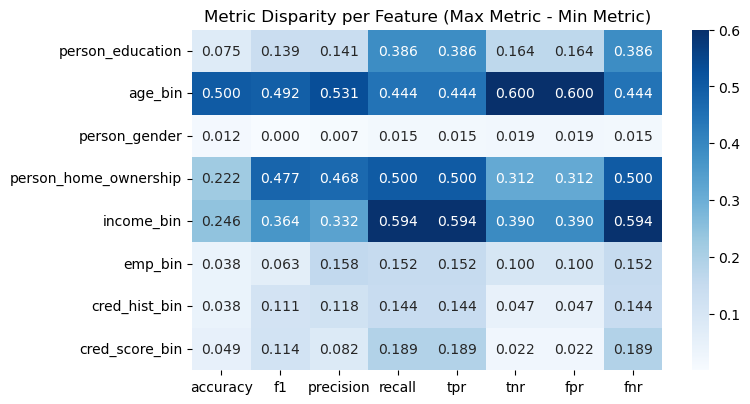

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.heatmap(final_summary_df, annot=True, cmap="Blues", fmt=".3f")
plt.tight_layout()
plt.title("Metric Disparity per Feature (Max Metric - Min Metric)")
plt.show()

In [17]:
summary_list = []

# for every feature identified, compute metrics
for col in sensitive_df.columns:
    metric = MetricFrame(
        metrics=metrics_dict,
        y_true=y_test,
        y_pred=y_pred_baseline_l2,
        sensitive_features=sensitive_df[col]
    )
    
    # compute median level for each feature
    feature_range = metric.by_group.median()
    
    # Label this row with the feature name
    feature_range.name = col
    summary_list.append(feature_range)


final_summary_df = pd.DataFrame(summary_list)

print(final_summary_df)

                       accuracy        f1  precision    recall       tpr       tnr       fpr       fnr
person_education       0.783019  0.590075   0.503409  0.755973  0.755973  0.791508  0.208492  0.244027
age_bin                0.777604  0.582238   0.494565  0.725625  0.725625  0.791819  0.208181  0.274375
person_gender          0.777748  0.596861   0.499462  0.741570  0.741570  0.787977  0.212023  0.258430
person_home_ownership  0.880860  0.527132   0.456214  0.645304  0.645304  0.924645  0.075355  0.354696
income_bin             0.864821  0.499603   0.496269  0.559039  0.559039  0.912481  0.087519  0.440961
emp_bin                0.790398  0.590361   0.496498  0.701863  0.701863  0.814447  0.185553  0.298137
cred_hist_bin          0.780000  0.606061   0.506160  0.718360  0.718360  0.807466  0.192534  0.281640
cred_score_bin         0.779052  0.606530   0.506848  0.742143  0.742143  0.789869  0.210131  0.257857


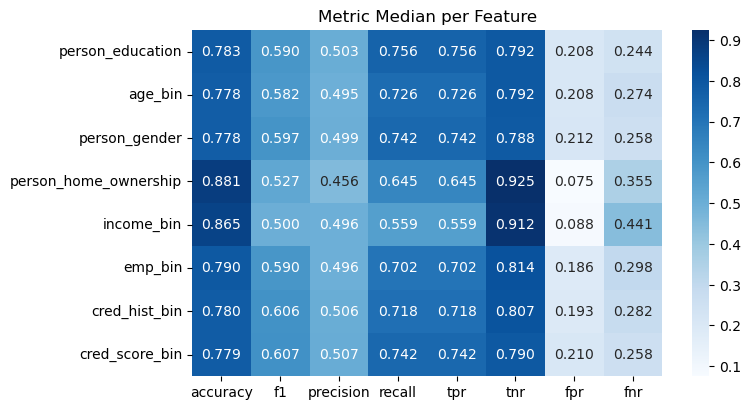

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.heatmap(final_summary_df, annot=True, cmap="Blues", fmt=".3f")
plt.tight_layout()
plt.title("Metric Median per Feature")
plt.show()

In [19]:
X_train_quantum = pd.read_csv("X_train_quantum_features_78_2_layer.csv")
X_test_quantum = pd.read_csv("X_test_quantum_features_78_2_layer.csv")

In [20]:
# Scale features to N(0,1) for logistic regression
scaler = StandardScaler()
X_train_quantum_scaled = scaler.fit_transform(X_train_quantum)
X_test_quantum_scaled = scaler.transform(X_test_quantum)

# Train model
clf_quantum = LogisticRegression(max_iter=1000)
clf_quantum.fit(X_train_quantum_scaled, y_train)

# Predict
y_train_pred_quantum = clf_quantum.predict(X_train_quantum_scaled)
y_test_pred_quantum = clf_quantum.predict(X_test_quantum_scaled)

print(f"Quantum_78 two layer training accuracy: {accuracy_score(y_train, y_train_pred_quantum)*100:.2f}%")
print(f"Quantum_78 two layer test accuracy: {accuracy_score(y_test, y_test_pred_quantum)*100:.2f}%")

Quantum_78 two layer training accuracy: 80.78%
Quantum_78 two layer test accuracy: 75.03%


In [21]:
# for each feature identified
for col in sensitive_df.columns:
    # 1. Create the MetricFrame for the current feature
    mf = MetricFrame(
        metrics=metrics_dict,
        y_true=y_test,
        y_pred=y_test_pred_quantum,
        sensitive_features=sensitive_df[col]
    )
    
    print(mf.by_group[['fpr', 'fnr']])

                       fpr       fnr
person_education                    
Associate         0.342034  0.166359
Bachelor          0.248092  0.192833
Doctorate         0.317073  0.333333
High School       0.243994  0.207156
Master            0.179441  0.298742
              fpr       fnr
age_bin                    
0-24     0.218699  0.202305
25-34    0.289062  0.205051
35-44    0.276812  0.188482
45-54    0.192982  0.407407
55-64    0.166667  0.666667
65+      0.800000  0.800000
                    fpr       fnr
person_gender                    
female         0.254151  0.221077
male           0.267649  0.197870
                            fpr       fnr
person_home_ownership                    
MORTGAGE               0.116584  0.528868
OTHER                  0.043478  0.833333
OWN                    0.236462  0.230769
RENT                   0.412259  0.113666
                 fpr       fnr
income_bin                    
0-40k       0.512438  0.103604
120k-160k   0.097668  0.338710
160k-

In [22]:
# for every feature identified, compute metrics
summary_list = []
for col in sensitive_df.columns:
    metric = MetricFrame(
        metrics=metrics_dict,
        y_true=y_test,
        y_pred=y_test_pred_quantum,
        sensitive_features=sensitive_df[col]
    )
    
    # compute max-min across levels for each feature
    feature_range = metric.by_group.apply(lambda x: x.max() - x.min())
    
    # Label this row with the feature name
    feature_range.name = col
    summary_list.append(feature_range)


final_summary_df = pd.DataFrame(summary_list)

print(final_summary_df)

                       accuracy        f1  precision    recall       tpr       tnr       fpr       fnr
person_education       0.114728  0.117854   0.147484  0.166975  0.166975  0.162593  0.162593  0.166975
age_bin                0.585251  0.441607   0.336606  0.611518  0.611518  0.633333  0.633333  0.611518
person_gender          0.004961  0.010724   0.005515  0.023206  0.023206  0.013499  0.013499  0.023206
person_home_ownership  0.150687  0.392993   0.318152  0.719667  0.719667  0.368781  0.368781  0.719667
income_bin             0.209564  0.412836   0.369453  0.434858  0.434858  0.414770  0.414770  0.434858
emp_bin                0.032405  0.069316   0.094104  0.299022  0.299022  0.104650  0.104650  0.299022
cred_hist_bin          0.160450  0.258153   0.163642  0.427139  0.427139  0.059923  0.059923  0.427139
cred_score_bin         0.086311  0.108487   0.144379  0.163245  0.163245  0.114041  0.114041  0.163245


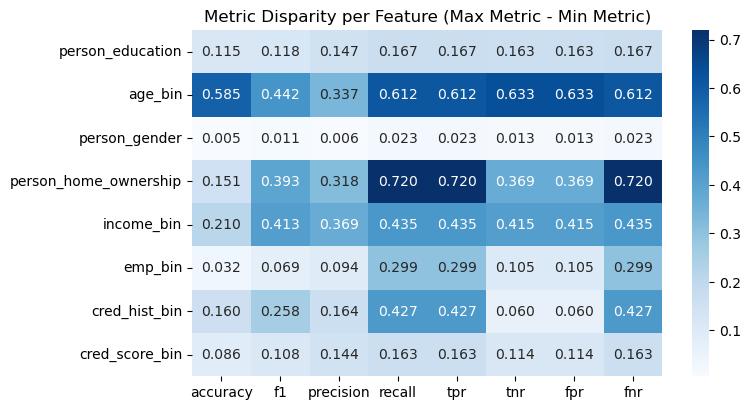

In [23]:
plt.figure(figsize=(8, 4))
sns.heatmap(final_summary_df, annot=True, cmap="Blues", fmt=".3f")
plt.tight_layout()
plt.title("Metric Disparity per Feature (Max Metric - Min Metric)")
plt.show()

In [24]:
# for every feature identified, compute metrics
summary_list = []
for col in sensitive_df.columns:
    metric = MetricFrame(
        metrics=metrics_dict,
        y_true=y_test,
        y_pred=y_test_pred_quantum,
        sensitive_features=sensitive_df[col]
    )
    
    # compute median levels for each feature
    feature_range = metric.by_group.median()
    
    # Label this row with the feature name
    feature_range.name = col
    summary_list.append(feature_range)


final_summary_df = pd.DataFrame(summary_list)

print(final_summary_df)

                       accuracy        f1  precision    recall       tpr       tnr       fpr       fnr
person_education       0.763982  0.597587   0.476334  0.792844  0.792844  0.751908  0.248092  0.207156
age_bin                0.735482  0.522294   0.422085  0.693771  0.693771  0.752245  0.247755  0.306229
person_gender          0.750578  0.584332   0.463462  0.790526  0.790526  0.739100  0.260900  0.209474
person_home_ownership  0.778508  0.351780   0.426471  0.620181  0.620181  0.823477  0.176523  0.379819
income_bin             0.827460  0.479272   0.382123  0.647809  0.647809  0.853914  0.146086  0.352191
emp_bin                0.750000  0.559524   0.448819  0.806295  0.806295  0.735517  0.264483  0.193705
cred_hist_bin          0.739403  0.548913   0.420833  0.789062  0.789062  0.726916  0.273084  0.210938
cred_score_bin         0.765724  0.589478   0.500786  0.802810  0.802810  0.779909  0.220091  0.197190


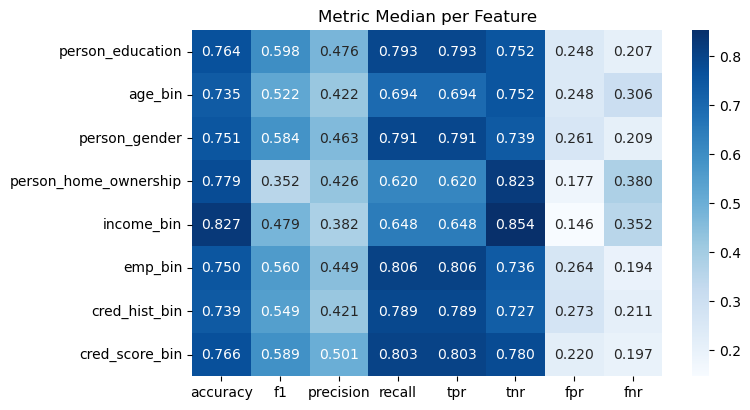

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.heatmap(final_summary_df, annot=True, cmap="Blues", fmt=".3f")
plt.tight_layout()
plt.title("Metric Median per Feature")
plt.show()